# Neural Trajectory Divergence Analysis

Analysis of GO vs STOP trial divergence using the Pani et al. (2022) methodology.

## 1. Setup and Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add paths for imports
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

from divergence_analyzer import TrajectoryDivergenceAnalyzer, DEFAULT_CONFIG
from cell_analysis import Cell

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
# Display default configuration
print("Default Configuration:")
print("=" * 40)
for key, value in DEFAULT_CONFIG.items():
    print(f"  {key}: {value}")

Default Configuration:
  tau_g: 1.0
  tau_d: 20.0
  kernel_duration: 20.0
  dt: 1.0
  epoch: [-50, 250]
  window_size_ms: 10
  n_samples: 100
  random_state: 42
  direction: 0
  ssd_number: 2.0
  min_trials: 5
  n_jobs: -1
  verbose: True


In [3]:
# Analysis configuration
config = {
    'epoch': [-50, 250],
    'window_size_ms': 10,
    'n_samples': 100,
    'direction': 0,
    'ssd_number': 2.0,
    'min_trials': 5,
    'n_jobs': -1,
    'random_state': 42,
    'verbose': True,
}

DIR_MAP = {0: 'Right', 180: 'Left'}

## 2. Load Data

In [4]:
# Load cell database
data_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data' / 'msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(data_path)

print(f"Loaded {len(cell_df)} rows")
print(f"Unique cells: {cell_df['cell_ID'].nunique()}")
print(f"Unique sessions: {cell_df['trial_session'].nunique()}")

Loaded 770705 rows
Unique cells: 1414
Unique sessions: 60


In [5]:
# Use single session for faster analysis
# session_name = 'fi211025a'
# data = cell_df[cell_df['trial_session'] == session_name].copy()

# To use all sessions instead, uncomment:
data = cell_df.copy()

print(f"Working with {len(data)} rows")
print(f"  Cells: {data['cell_ID'].nunique()}")
print(f"  Sessions: {data['trial_session'].nunique()}")

Working with 770705 rows
  Cells: 1414
  Sessions: 60


## 3. Data Preprocessing

In [6]:
def filter_go_trials_by_saccade_timing(session_data, direction, ssd_number, ssd_multiplier=1.5):
    """Remove GO trials where saccade occurs before the expected stop signal."""
    stop_trials = session_data[
        (session_data['type'] == 'STOP') & 
        (session_data['trial_failed'] == False) & 
        (session_data['dir'] == direction) &
        (session_data['ssd_number'] == ssd_number)
    ]
    mean_ssd = stop_trials['ssd_len'].mean()
    threshold = mean_ssd * ssd_multiplier
    
    print(f"Mean SSD: {mean_ssd:.2f} ms")
    print(f"Saccade threshold: {threshold:.2f} ms after go_cue")
    
    def is_valid_go_trial(row):
        if row['type'] != 'GO':
            return True
        try:
            if pd.isna(row['first_relevant_saccade']).any():
                return False
            saccade_onset = row['first_relevant_saccade'][0]
        except (TypeError, AttributeError):
            if pd.isna(row['first_relevant_saccade']):
                return False
            saccade_onset = row['first_relevant_saccade']
        return (saccade_onset - row['go_cue']) > threshold
    
    original_count = len(session_data)
    filtered_data = session_data[session_data.apply(is_valid_go_trial, axis=1)]
    removed_count = original_count - len(filtered_data)
    
    print(f"Removed {removed_count} rows ({removed_count/original_count*100:.1f}%)")
    return filtered_data, mean_ssd

In [7]:
# Apply GO trial filtering
data, mean_ssd = filter_go_trials_by_saccade_timing(
    data, 
    direction=config['direction'], 
    ssd_number=config['ssd_number']
)
print(f"\nFinal dataset: {len(data)} rows, {data['cell_ID'].nunique()} cells")

Mean SSD: 109.83 ms
Saccade threshold: 164.75 ms after go_cue
Removed 115439 rows (15.0%)

Final dataset: 655266 rows, 1414 cells


## 4. Trial Count Summary

In [8]:
direction = config['direction']
ssd_num = config['ssd_number']

def count_trials(df, trial_type, direction, ssd_number=None):
    mask = (df['type'] == trial_type) & (df['dir'] == direction) & (df['trial_failed'] == False)
    if ssd_number is not None:
        mask &= (df['ssd_number'] == ssd_number)
    return df[mask]['trial_number'].nunique()

print(f"Trial Counts for {DIR_MAP[direction]} direction:")
print("=" * 40)
print(f"GO trials: {count_trials(data, 'GO', direction)}")
print(f"STOP SSD{ssd_num} trials: {count_trials(data, 'STOP', direction, ssd_num)}")
print(f"CONT SSD{ssd_num} trials: {count_trials(data, 'CONT', direction, ssd_num)}")

Trial Counts for Right direction:
GO trials: 969
STOP SSD2.0 trials: 504
CONT SSD2.0 trials: 557


## 5. Initialize Analyzer and Run Population Analysis

In [9]:
# Create analyzer instance
analyzer = TrajectoryDivergenceAnalyzer(data, config=config)

TrajectoryDivergenceAnalyzer initialized
  Cells: 1414
  Trials: 1013
  Direction: 0
  SSD: 2.0


In [10]:
# Get valid cells
valid_cells = analyzer.get_valid_cells()
print(f"Valid cells for analysis: {len(valid_cells)}")

Valid cells for analysis: 1303


In [11]:
# Run population analysis
results = analyzer.analyze_population()

Found 1303 valid cells for analysis
Pre-chunking data for 1303 neurons...


Chunking:   0%|          | 0/1303 [00:00<?, ?it/s]

Analyzing 1303 neurons in parallel...


Processing:   0%|          | 0/1303 [00:00<?, ?it/s]

Successfully analyzed: 1303/1303 neurons

Population Statistics (1303 neurons):
  Peak divergence: 4.05 at 245.5 ms
  Mean peak time (per neuron): 105.0 ms (std: 87.2 ms)


In [12]:
print(analyzer.summary())

TrajectoryDivergenceAnalyzer Summary
Direction: 0 (Right)
SSD: 2.0
Epoch: [-50, 250] ms
Window size: 10 ms
N samples: 100

Results:
  Analyzed neurons: 1303
  Failed neurons: 0
  Population peak divergence: 4.05 at 245.5 ms


## 6. Statistical Analysis

In [13]:
stats_results = analyzer.run_paired_ttest(window=(-50, 50), align_to_peak=True)


Paired t-test Results (n=1303):
  Window: (-50, 50) ms (relative to peak)
  GO mean: 12.44 ± 11.28
  STOP mean: 13.75 ± 11.94
  t = 12.3335, p = 3.9086e-33
  Cohen's d = 0.342


## 7. Create Aligned PSTH Database

In [14]:
psth_database = analyzer.create_aligned_psth_database(
    cell_class=Cell,
    trial_types=['GO', 'STOP', 'CONT'],
    bin_size=1,
    smooth=True,
    smooth_ker_size=25
)
print(f"\nPSTH Database: {len(psth_database)} entries")
print(f"Trial types: {psth_database['trial_type'].unique()}")

Creating aligned PSTH database:   0%|          | 0/1303 [00:00<?, ?it/s]


PSTH Database: 3909 entries
Trial types: ['GO' 'STOP' 'CONT']


---
# Visualization Section
---

## 8. Population Divergence Plots

In [15]:
def plot_population_divergence(analyzer, mean_ssd=None, figsize=(14, 10)):
    """Plot population-level divergence analysis."""
    results = analyzer.results
    t_centers = results['t_centers']
    direction = analyzer.config['direction']
    ssd_num = analyzer.config['ssd_number']
    window_size = analyzer.config['window_size_ms']
    
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    # Panel 1: GO-GO vs GO-STOP
    ax1 = axes[0]
    ax1.plot(t_centers, results['go_go_population_mean'], 'b-', lw=2.5, label='GO-GO baseline')
    ax1.fill_between(t_centers,
                     results['go_go_population_mean'] - results['go_go_population_sem'],
                     results['go_go_population_mean'] + results['go_go_population_sem'],
                     color='blue', alpha=0.3)
    ax1.plot(t_centers, results['go_stop_population_mean'], 'r-', lw=2.5, label='GO-STOP')
    ax1.fill_between(t_centers,
                     results['go_stop_population_mean'] - results['go_stop_population_sem'],
                     results['go_stop_population_mean'] + results['go_stop_population_sem'],
                     color='red', alpha=0.3)
    ax1.axvline(0, color='green', ls='--', lw=2, alpha=0.6, label='GO cue')
    if mean_ssd is not None:
        ax1.axvline(mean_ssd, color='darkred', ls='--', lw=2, alpha=0.6, label=f'Mean SSD ({mean_ssd:.0f} ms)')
    ax1.set_ylabel(f'Distance ({window_size} ms window)')
    ax1.set_title(f'Population Divergence - {DIR_MAP[direction]} Direction, SSD{ssd_num}\n'
                  f'{results["n_successful"]} neurons', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)
    ax1.set_ylim(bottom=0)
    
    # Panel 2: Divergence signal
    ax2 = axes[1]
    ax2.plot(t_centers, results['divergence_population_mean'], 'purple', lw=2.5)
    ax2.fill_between(t_centers,
                     results['divergence_population_mean'] - results['divergence_population_sem'],
                     results['divergence_population_mean'] + results['divergence_population_sem'],
                     color='purple', alpha=0.3)
    ax2.axhline(0, color='black', ls='-', lw=1, alpha=0.5)
    ax2.axvline(0, color='green', ls='--', lw=2, alpha=0.6)
    if mean_ssd is not None:
        ax2.axvline(mean_ssd, color='darkred', ls='--', lw=2, alpha=0.6)
    peak_time = results['population_peak_divergence_time']
    peak_val = results['population_peak_divergence_value']
    ax2.plot(peak_time, peak_val, 'ro', ms=10, zorder=5)
    ax2.annotate(f'Peak: {peak_time:.0f} ms\n({peak_val:.2f})',
                 xy=(peak_time, peak_val), xytext=(peak_time + 20, peak_val),
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    ax2.set_ylabel('Divergence (|GO-STOP - GO-GO|)')
    ax2.set_xlabel('Time relative to GO cue (ms)')
    ax2.grid(alpha=0.3)
    
    # Panel 3: Histogram
    ax3 = axes[2]
    peak_times = results['peak_divergence_time']
    ax3.hist(peak_times, bins=20, color='purple', alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(peak_times), color='red', ls='-', lw=2, label=f'Mean: {np.mean(peak_times):.0f} ms')
    ax3.axvline(np.median(peak_times), color='orange', ls='--', lw=2, label=f'Median: {np.median(peak_times):.0f} ms')
    ax3.set_xlabel('Peak divergence time (ms)')
    ax3.set_ylabel('Number of neurons')
    ax3.set_title('Distribution of Peak Divergence Times')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

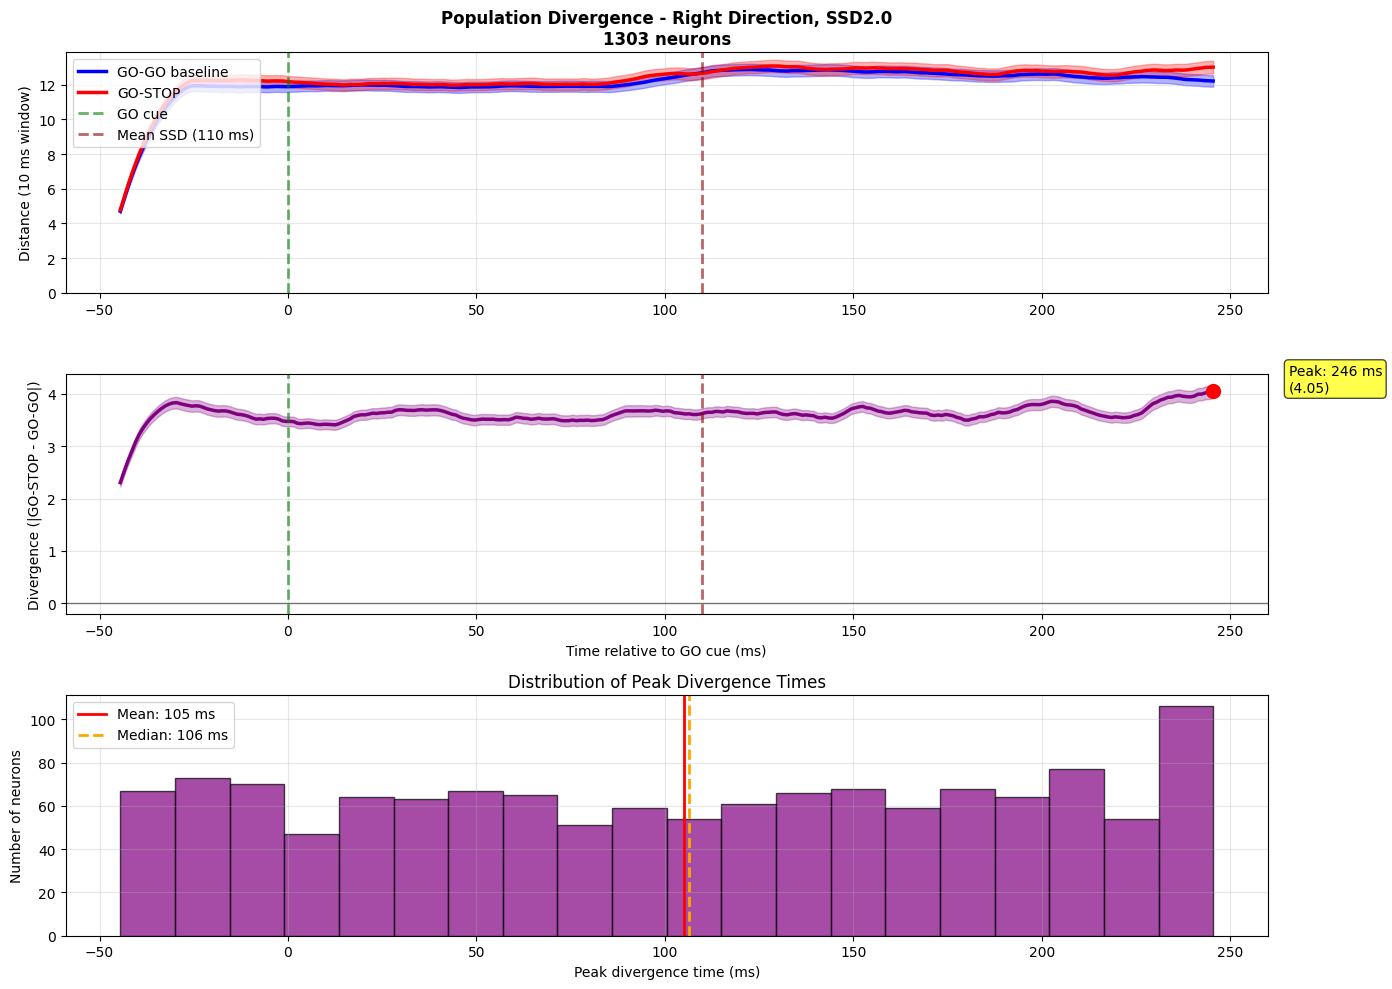

In [16]:
fig = plot_population_divergence(analyzer, mean_ssd=mean_ssd)
plt.show()

## 9. Population PSTH Aligned to Peak Divergence

In [17]:
def plot_population_psth_aligned_to_peak(analyzer, psth_database, figsize=(12, 7)):
    """Plot population average PSTH aligned to peak divergence time."""
    common_time = np.arange(-250, 251, 1)
    
    go_mean, go_sem, _ = analyzer.get_population_psth_stats(psth_database, 'GO', common_time)
    stop_mean, stop_sem, _ = analyzer.get_population_psth_stats(psth_database, 'STOP', common_time)
    cont_mean, cont_sem, _ = analyzer.get_population_psth_stats(psth_database, 'CONT', common_time)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if go_mean is not None:
        ax.plot(common_time, go_mean, 'b-', lw=2.5, label='GO')
        ax.fill_between(common_time, go_mean - go_sem, go_mean + go_sem, color='blue', alpha=0.2)
    if stop_mean is not None:
        ax.plot(common_time, stop_mean, 'r-', lw=2.5, label='STOP (success)')
        ax.fill_between(common_time, stop_mean - stop_sem, stop_mean + stop_sem, color='red', alpha=0.2)
    if cont_mean is not None:
        ax.plot(common_time, cont_mean, 'g:', lw=2.5, label='CONT')
        ax.fill_between(common_time, cont_mean - cont_sem, cont_mean + cont_sem, color='green', alpha=0.2)
    
    ax.axvline(0, color='purple', ls='--', lw=2, alpha=0.8, label='Peak divergence (t=0)')
    ax.set_xlabel('Time relative to peak divergence (ms)')
    ax.set_ylabel('Firing rate (spks/s)')
    ax.set_title(f'Population PSTH Aligned to Peak Divergence\n{len(psth_database["cell_id"].unique())} neurons',
                 fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

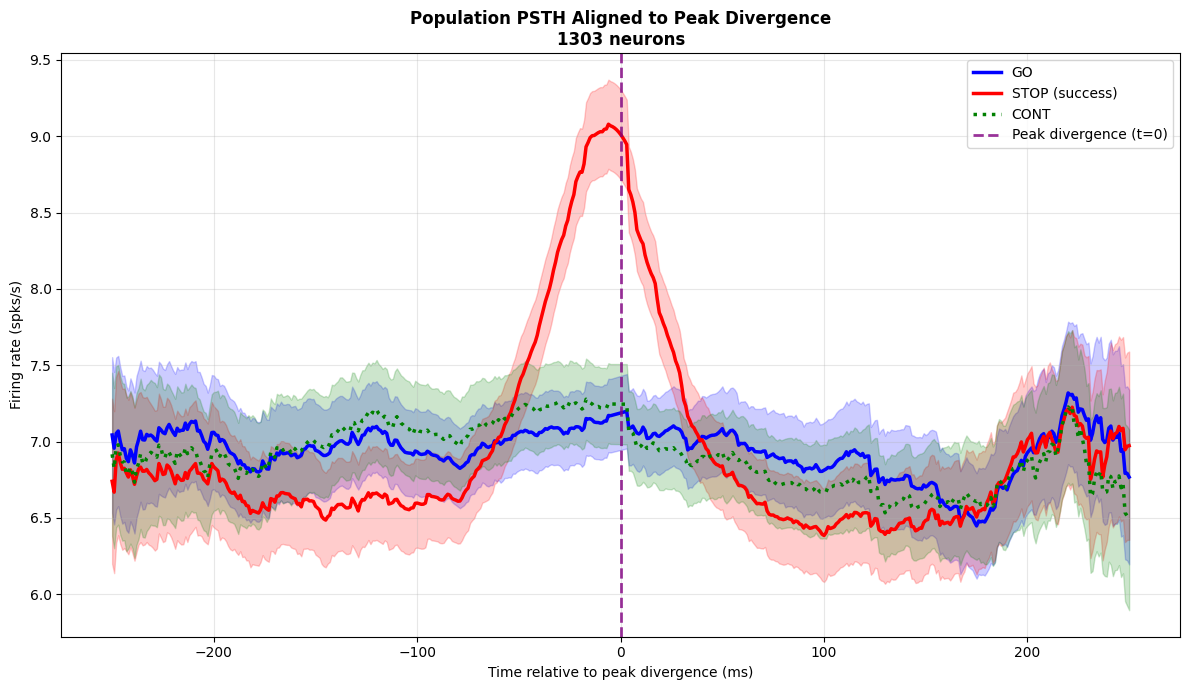

In [18]:
fig = plot_population_psth_aligned_to_peak(analyzer, psth_database)
plt.show()

## 10. Single Neuron Visualization

In [19]:
def plot_single_neuron_divergence(analyzer, cell_idx, error_type='sem', figsize=(14, 8)):
    """Plot divergence analysis for a single neuron."""
    neuron_data = analyzer.get_neuron_data(cell_idx)
    t_centers = neuron_data['t_centers']
    n_samples = analyzer.config['n_samples']
    
    if error_type == 'sem':
        go_go_err = neuron_data['go_go_std'] / np.sqrt(n_samples)
        go_stop_err = neuron_data['go_stop_std'] / np.sqrt(n_samples)
        err_label = 'SEM'
    else:
        go_go_err = neuron_data['go_go_std']
        go_stop_err = neuron_data['go_stop_std']
        err_label = 'SD'
    
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    ax1 = axes[0]
    ax1.plot(t_centers, neuron_data['go_go_mean'], 'b-', lw=2, label='GO-GO')
    ax1.fill_between(t_centers, neuron_data['go_go_mean'] - go_go_err, 
                     neuron_data['go_go_mean'] + go_go_err, color='blue', alpha=0.3)
    ax1.plot(t_centers, neuron_data['go_stop_mean'], 'r-', lw=2, label='GO-STOP')
    ax1.fill_between(t_centers, neuron_data['go_stop_mean'] - go_stop_err,
                     neuron_data['go_stop_mean'] + go_stop_err, color='red', alpha=0.3)
    ax1.axvline(0, color='green', ls='--', lw=2, alpha=0.6, label='GO cue')
    ax1.set_ylabel(f'Distance +/- {err_label}')
    ax1.set_title(f'Neuron {neuron_data["cell_id"]} - Divergence Analysis', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    ax2.plot(t_centers, neuron_data['divergence_mean'], 'purple', lw=2)
    ax2.axhline(0, color='black', ls='-', lw=1, alpha=0.5)
    ax2.axvline(0, color='green', ls='--', lw=2, alpha=0.6)
    ax2.plot(neuron_data['peak_time'], neuron_data['peak_value'], 'ro', ms=10, zorder=5)
    ax2.annotate(f'Peak: {neuron_data["peak_time"]:.0f} ms',
                 xy=(neuron_data['peak_time'], neuron_data['peak_value']),
                 xytext=(neuron_data['peak_time'] + 15, neuron_data['peak_value']),
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    ax2.set_xlabel('Time relative to GO cue (ms)')
    ax2.set_ylabel('Divergence')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

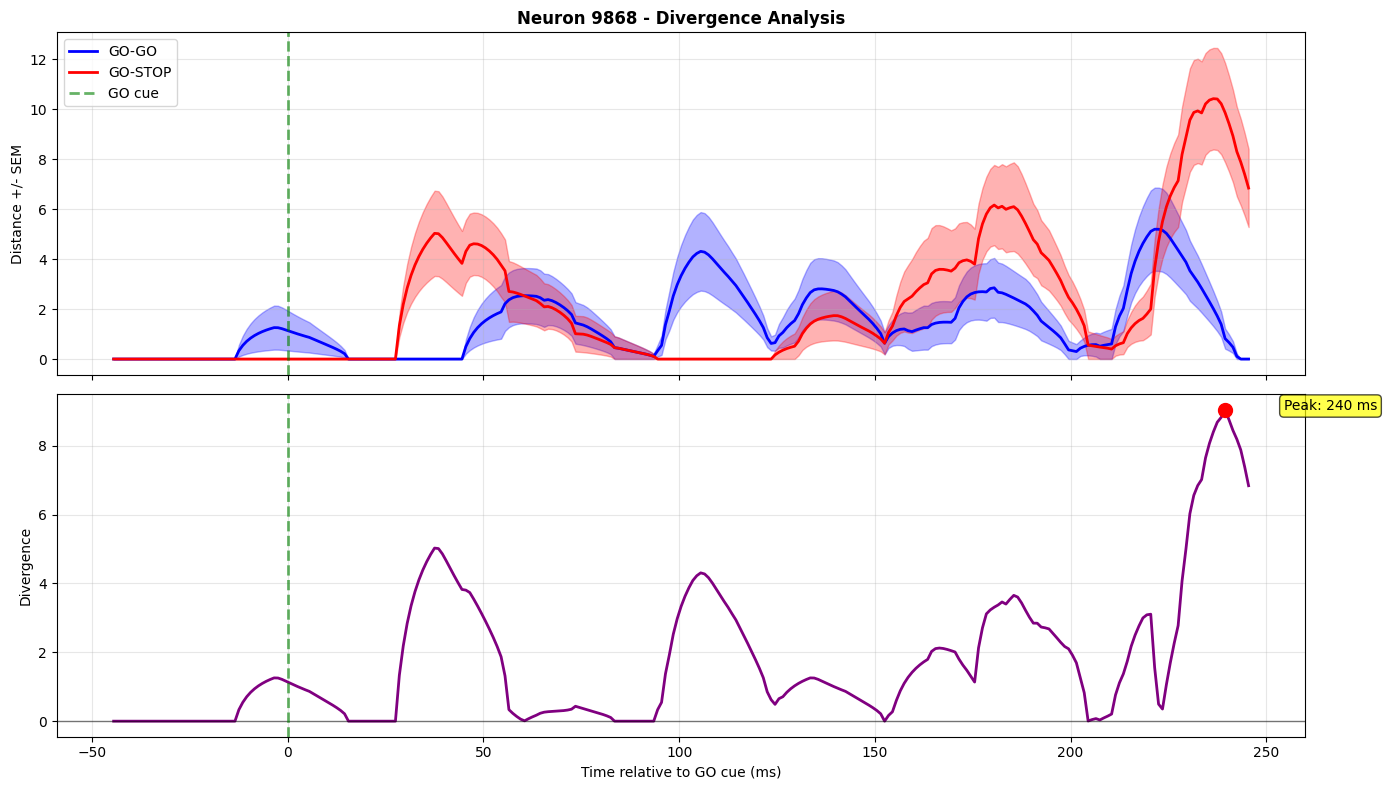

In [20]:
# Plot single neuron (change index to browse)
cell_idx = 0
fig = plot_single_neuron_divergence(analyzer, cell_idx, error_type='sem')
plt.show()

---
# Interactive Dashboard Section
---

## 11. Neuron Browser Dashboard

In [21]:
import panel as pn
pn.extension()

In [22]:
def create_neuron_browser_dashboard(analyzer, session_data, Cell):
    """Create interactive dashboard for browsing neurons."""
    cell_ids = analyzer.results['cell_ids']
    direction = analyzer.config['direction']
    ssd_num = analyzer.config['ssd_number']
    n_samples = analyzer.config['n_samples']
    
    cell_select = pn.widgets.Select(
        name='Neuron', 
        options={str(cid): i for i, cid in enumerate(cell_ids)},
        value=0, width=150
    )
    error_select = pn.widgets.Select(name='Error Type', options=['std', 'sem'], value='sem', width=100)
    prev_btn = pn.widgets.Button(name='< Prev', width=80)
    next_btn = pn.widgets.Button(name='Next >', width=80)
    
    def navigate(event):
        current = cell_select.value
        if event.obj.name == '< Prev':
            cell_select.value = (current - 1) % len(cell_ids)
        else:
            cell_select.value = (current + 1) % len(cell_ids)
    
    prev_btn.on_click(navigate)
    next_btn.on_click(navigate)
    
    @pn.depends(cell_select.param.value, error_select.param.value)
    def plot_neuron(cell_idx, error_type):
        neuron_data = analyzer.get_neuron_data(cell_idx)
        cell_id = neuron_data['cell_id']
        t_centers = neuron_data['t_centers']
        
        if error_type == 'sem':
            go_go_err = neuron_data['go_go_std'] / np.sqrt(n_samples)
            go_stop_err = neuron_data['go_stop_std'] / np.sqrt(n_samples)
        else:
            go_go_err = neuron_data['go_go_std']
            go_stop_err = neuron_data['go_stop_std']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        ax = axes[0, 0]
        ax.plot(t_centers, neuron_data['go_go_mean'], 'b-', lw=2, label='GO-GO')
        ax.fill_between(t_centers, neuron_data['go_go_mean'] - go_go_err,
                        neuron_data['go_go_mean'] + go_go_err, color='blue', alpha=0.3)
        ax.plot(t_centers, neuron_data['go_stop_mean'], 'r-', lw=2, label='GO-STOP')
        ax.fill_between(t_centers, neuron_data['go_stop_mean'] - go_stop_err,
                        neuron_data['go_stop_mean'] + go_stop_err, color='red', alpha=0.3)
        ax.axvline(0, color='green', ls='--', lw=2, alpha=0.6)
        ax.set_title('Distance Comparison', fontweight='bold')
        ax.set_ylabel(f'Distance +/- {error_type.upper()}')
        ax.legend(loc='upper left')
        ax.grid(alpha=0.3)
        
        ax = axes[0, 1]
        ax.plot(t_centers, neuron_data['divergence_mean'], 'purple', lw=2)
        ax.axhline(0, color='black', ls='-', lw=1, alpha=0.5)
        ax.axvline(0, color='green', ls='--', lw=2, alpha=0.6)
        ax.plot(neuron_data['peak_time'], neuron_data['peak_value'], 'ro', ms=10)
        ax.set_title(f'Divergence (Peak: {neuron_data["peak_time"]:.0f} ms)', fontweight='bold')
        ax.set_ylabel('|GO-STOP - GO-GO|')
        ax.grid(alpha=0.3)
        
        cell_data_df = session_data[session_data['cell_ID'] == cell_id]
        cell = Cell(cell_data_df, verbose=False)
        
        ax = axes[1, 0]
        for trial_type, color in [('GO', 'blue'), ('STOP', 'red')]:
            ssd = ssd_num if trial_type == 'STOP' else None
            bins, fr, n = cell.calculate_psth(
                epok=analyzer.config['epoch'], bin_size=1, trial_type=trial_type,
                direction=direction, ssd_number=ssd, smooth=True, smooth_ker_size=25
            )
            if bins is not None:
                ax.plot(bins, fr, color=color, lw=2, label=f'{trial_type} (n={n})')
        ax.axvline(0, color='green', ls='--', lw=2, alpha=0.6)
        ax.set_title('PSTH', fontweight='bold')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Firing rate (spks/s)')
        ax.legend()
        ax.grid(alpha=0.3)
        
        ax = axes[1, 1]
        ax.axis('off')
        info_text = f"Cell ID: {cell_id}\nDirection: {DIR_MAP[direction]}\nSSD: {ssd_num}\n\n"
        info_text += f"Peak Divergence:\n  Time: {neuron_data['peak_time']:.1f} ms\n  Value: {neuron_data['peak_value']:.3f}\n\n"
        info_text += f"Population Avg Peak: {analyzer.results['population_peak_divergence_time']:.1f} ms"
        ax.text(0.1, 0.9, info_text, transform=ax.transAxes, fontsize=12, verticalalignment='top',
                fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        fig.suptitle(f'Neuron {cell_id} ({cell_idx + 1}/{len(cell_ids)})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.close(fig)
        return fig
    
    controls = pn.Row(prev_btn, cell_select, next_btn, error_select)
    return pn.Column(controls, plot_neuron)

In [23]:
dashboard = create_neuron_browser_dashboard(analyzer, data, Cell)
dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'1a9e63ab-c430-4b93-9828-302673e0a893': {'version…

## 12. Aligned PSTH Browser

In [24]:
def create_aligned_psth_dashboard(psth_database):
    """Create dashboard for browsing aligned PSTHs."""
    cell_ids = sorted(psth_database['cell_id'].unique())
    
    cell_select = pn.widgets.Select(name='Neuron ID', options=cell_ids, value=cell_ids[0], width=150)
    prev_btn = pn.widgets.Button(name='< Prev', width=80)
    next_btn = pn.widgets.Button(name='Next >', width=80)
    
    def navigate(event):
        current_idx = cell_ids.index(cell_select.value)
        if event.obj.name == '< Prev':
            new_idx = (current_idx - 1) % len(cell_ids)
        else:
            new_idx = (current_idx + 1) % len(cell_ids)
        cell_select.value = cell_ids[new_idx]
    
    prev_btn.on_click(navigate)
    next_btn.on_click(navigate)
    
    @pn.depends(cell_select.param.value)
    def plot_aligned(cell_id):
        cell_data = psth_database[psth_database['cell_id'] == cell_id]
        if cell_data.empty:
            return pn.pane.Markdown(f"No data for cell {cell_id}")
        
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = {'GO': 'blue', 'STOP': 'red', 'CONT': 'green'}
        linestyles = {'GO': '-', 'STOP': '-', 'CONT': ':'}
        
        for _, row in cell_data.iterrows():
            trial_type = row['trial_type']
            ax.plot(row['time'], row['firing_rate'], color=colors.get(trial_type, 'gray'),
                    ls=linestyles.get(trial_type, '-'), lw=2, label=f"{trial_type} (n={row['n_trials']})")
        
        ax.axvline(0, color='purple', ls='--', lw=2, alpha=0.8, label='Peak divergence')
        go_row = cell_data[cell_data['trial_type'] == 'GO'].iloc[0]
        ax.axvline(go_row['go_cue_aligned_time'], color='green', ls='--', lw=2, alpha=0.6, label='GO cue')
        if not pd.isna(go_row['stop_signal_aligned_time']):
            ax.axvline(go_row['stop_signal_aligned_time'], color='darkred', ls='--', lw=2, alpha=0.6, label='Stop signal')
        
        ax.set_xlabel('Time relative to peak divergence (ms)')
        ax.set_ylabel('Firing rate (spks/s)')
        ax.set_title(f'Neuron {cell_id} - PSTH Aligned to Peak Divergence', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.close(fig)
        return fig
    
    controls = pn.Row(prev_btn, cell_select, next_btn)
    return pn.Column(controls, plot_aligned)

In [25]:
aligned_dashboard = create_aligned_psth_dashboard(psth_database)
aligned_dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'9f6104c4-37ed-4e3a-8f9c-1da8c15e0b45': {'version…

## 13. Save Results

In [26]:
# Save results (optional)
# output_dir = Path.cwd().parents[1] / 'data' / 'divergence_results'
# output_dir.mkdir(exist_ok=True)
# psth_database.to_pickle(output_dir / 'aligned_psth_database.pkl')